In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle


In [3]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [4]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)
color_list1 = palette_tab10[1:2] + ["gold"]
color_list2 = palette_tab10[0:1]  + palette_tab10[9:10]

In [5]:

odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [6]:
odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-sum_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10 = pickle.load(f)

In [7]:
iend = 200

In [8]:
from nbodykit import cosmology

cosmo1 = cosmology.Planck15
z=1.5
Plin = cosmology.LinearPower(cosmo1, redshift=z, transfer='EisensteinHu') 
Pnl = cosmology.power.halofit.HalofitPower(cosmo1, redshift=z) 

#k_analytical = 10**np.arange(-1.6,0,0.05)
#k_colossus = 10**np.arange(-3,0,0.02)
ks = Pk_gal10['k'][:iend]
coef = ks**3 / (2 * np.pi **2)
Pk_linear = Plin(ks)
normed_Pk_matter_lin = coef * Pk_linear 
Pk_nonlinear = Pnl(ks)
normed_Pk_matter_nl = coef * Pk_nonlinear 

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


Text(0, 0.5, '$(P/P_{\\mathrm{linear}})^{1/2}$')

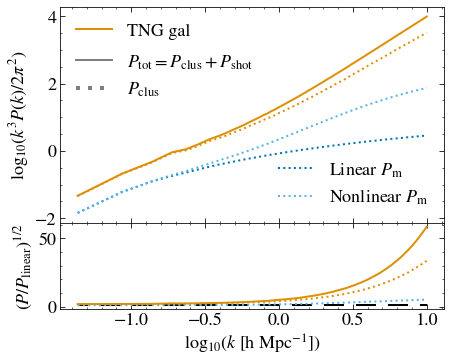

In [14]:
#fig,ax = plt.subplots()
figsize = (2*10/3,2*3)
fig1 = plt.figure(figsize=figsize)
ax = fig1.add_axes((.15,.3,.8,.5))
plt.plot(np.log10(ks), np.log10(coef * Pk_gal10["power"][:iend]), label="TNG total", color=color_list1[0])
#plt.plot(np.log10(ks), np.log10(coef * Pk_sum10["power"][:iend]), label="TNG total", color=color_list1[1])
plt.plot(np.log10(ks), np.log10(coef * (Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
#plt.plot(np.log10(ks), np.log10(coef * (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (group)", color=color_list1[1])

plt.plot(np.log10(ks), np.log10(normed_Pk_matter_lin), label="linear x 4", color = color_list2[0], linestyle="dotted")
plt.plot(np.log10(ks), np.log10(normed_Pk_matter_nl), label="nonlinear x 4", color = color_list2[1], linestyle="dotted")
plt.xlabel(r"$\mathrm{log_{10}} (k\ \mathrm{[h\ Mpc^{-1}}])$")
plt.ylabel(r"$ \mathrm{log_{10}}(k^3 P(k)/2\pi^2)$")
#plt.xlim(-1.5, 0.5)

label_list = ["TNG gal"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list1[i], linestyle="solid", label=label)
    solid_lines.append(solid_line)

first_legend = ax.legend(handles=solid_lines, frameon=False)
ax.add_artist(first_legend)
label_list = ["Linear $P_\mathrm{m}$", "Nonlinear $P_\mathrm{m}$"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list2[i], linestyle="dotted", label=label)
    solid_lines.append(solid_line)
    
second_legend = ax.legend(handles=solid_lines, frameon=False, loc="lower right", bbox_to_anchor = (1,0))
ax.add_artist(second_legend)

color="grey"
total_ps_leg = Line2D([],[],color=color, linestyle="solid", label=r"$P_\mathrm{tot} = P_{\rm clus} + P_{\rm shot}$")
shotnoise_subtracted_ps_leg = Line2D([],[],color=color,linestyle=(0, (1, 2)), label=r"$P_{\mathrm{clus}}$", linewidth=4)
leg_list = [total_ps_leg, shotnoise_subtracted_ps_leg]
ax.legend(handles=leg_list,bbox_to_anchor=(0,0.5), loc="lower left", frameon=False)

frame2 = fig1.add_axes((.15,.1,.8,.2))

linewidth1=1
plt.plot([np.log10(ks[0]),np.log10(ks[-1])], [1,1], linestyle=(5, (10/linewidth1, 6/linewidth1)), color="k")

plt.plot(np.log10(ks), np.sqrt(Pk_gal10["power"][:iend]/Pk_linear), label="TNG total", color=color_list1[0])
plt.plot(np.log10(ks), np.sqrt(Pk_nonlinear/Pk_linear), label="TNG total", linestyle="dotted", color=color_list2[1])

#plt.plot(np.log10(ks), coef * Pk_sum10["power"][:iend]/(pksum2_ratio*normed_Pk_matter_lin), label="TNG total", color=color_list1[1])
#plt.plot(np.log10(ks),np.sqrt((Pk_gal10["power"][:iend]-Pk_sum10.attrs["shotnoise"])/Pk_linear), linestyle="dotted", label="TNG clustering (gal)", color="red")
plt.plot(np.log10(ks),np.sqrt((Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])/Pk_linear), linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
#plt.plot(np.log10(ks), coef * (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])/(pksum2_ratio*normed_Pk_matter_lin), linestyle="dotted", label="TNG clustering (group)", color=color_list1[1])
plt.xlabel(r"$\mathrm{log_{10}(}k\ \mathrm{[h\ Mpc^{-1}])}$")
#plt.ylim(0.9,3.5)
plt.ylabel("$(P/P_{\mathrm{linear}})^{1/2}$")
#plt.savefig("../figures/tng_vs_matter.pdf", format="pdf", bbox_inches="tight")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


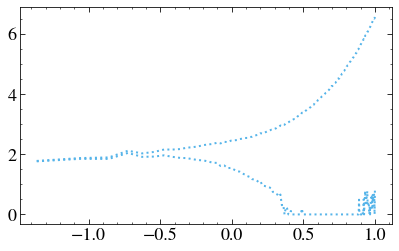

In [16]:
plt.plot(np.log10(ks), np.sqrt((Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])/Pk_nonlinear), label="TNG total", linestyle="dotted", color=color_list2[1])
plt.plot(np.log10(ks), np.sqrt((Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])/Pk_nonlinear), label="TNG total", linestyle="dotted", color=color_list2[1])


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


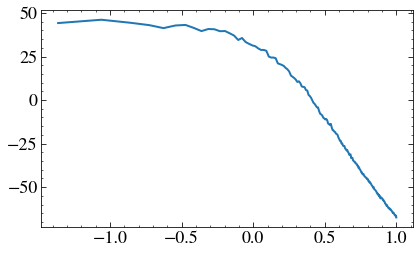

In [22]:
plt.plot(np.log10(ks), (Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"] -Pk_gal10.attrs["shotnoise"] - (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"]) ))
                               

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


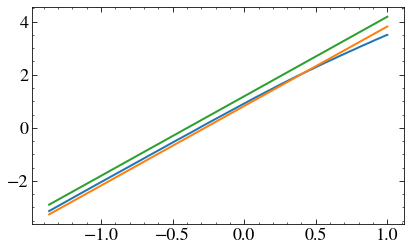

In [26]:
plt.plot(np.log10(ks), np.log10(coef*(Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"] -(Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"]) )))
plt.plot(np.log10(ks), np.log10(coef*Pk_gal10.attrs["shotnoise"]))
plt.plot(np.log10(ks), np.log10(coef*Pk_sum10.attrs["shotnoise"]))

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


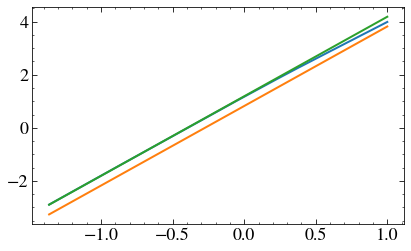

In [27]:
plt.plot(np.log10(ks), np.log10(coef*(Pk_gal10["power"][:iend]-(Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"]) )))
plt.plot(np.log10(ks), np.log10(coef*Pk_gal10.attrs["shotnoise"]))
plt.plot(np.log10(ks), np.log10(coef*Pk_sum10.attrs["shotnoise"]))

In [32]:
tot = (Pk_gal10["power"][:iend]-(Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"]))

In [34]:
shot_gal = Pk_gal10.attrs["shotnoise"]
shot_halo = Pk_sum10.attrs["shotnoise"]

In [35]:
uk = (tot - shot_gal)/(shot_halo - shot_gal)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


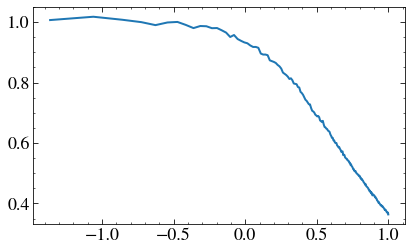

In [36]:
plt.plot(np.log10(ks), uk)

In [41]:
from colossus.cosmology import cosmology
from colossus.halo import profile_nfw

cosmo = cosmology.setCosmology('planck15')
p_nfw = profile_nfw.NFWProfile(M = 1E12, c = 10.0, z = 1.5, mdef = 'vir')

In [50]:
p_nfw.par

OrderedDict([('rhos', 57197494.395413235), ('rs', 9.776689731532189)])

In [90]:
physical_rho0 = p_nfw.par["rhos"]*(1e3)**3
print(physical_rho0)
physical_rs = p_nfw.par["rs"]/(1e3)

# convert to comoving
z = 1.5
rho0 = physical_rho0*(1+z)
rs = physical_rs*(1+z)
print(rho0)
print(rs)
rho0 = 1e7 * (1e3)**3
rs = 0.02


5.719749439541323e+16
1.4299373598853309e+17
0.02444172432883047


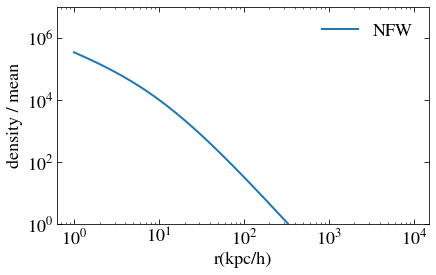

In [43]:
r = 10**np.arange(0,4,0.02)
rho_m = cosmo.rho_m(z)
rho_nfw = p_nfw.density(r)
plt.figure()
plt.loglog()
plt.xlabel('r(kpc/h)')
plt.ylabel('density / mean')
plt.plot(r, rho_nfw / rho_m, '-', label = 'NFW');
plt.ylim(1E0, 1E7)
plt.legend();

In [167]:
def my_ft(k_values,  r_s, rvir):
    fourier_transform = np.zeros_like(k_values)
    
    c = rvir/r_s
    print(c)
    for i, k in enumerate(k_values):
        kr_s = k * r_s
        Si_c, Ci_c = sici((1+c)*kr_s)
        Si, Ci = sici(kr_s)
        f = 1/(np.log(1+c) - c/(1+c))
        term1 = np.sin(kr_s) * (Si_c - Si)
        term2 = np.cos(kr_s) * (Ci_c - Ci)
        term3 = -np.sin(c*kr_s)/((1+c)*kr_s)
        fourier_transform[i] = f*(term1 + term2 + term3)
    
    return fourier_transform

In [168]:
rho0_pkpc_h = 6733038.060385219
rs_pkpc_h = 24.44172432883047
70.2107983709715
#r_vals_cmpc_h = r_vals_pkpc_h * pkpc_h_to_cmpc_h(z0)
z0=1.5
rs_0 = rs_pkpc_h * pkpc_h_to_cmpc_h(z0)
rho_0 = rho0_pkpc_h / (pkpc_h_to_cmpc_h(z0)**3)
rvir = 0.5
    
nfw_ft = my_ft(ks_test, rs_0, rvir)

8.18272873506261


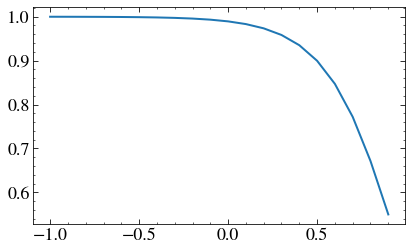

In [169]:
plt.plot(logks_test, nfw_ft)

In [102]:
from scipy.special import sici

def nfw_fourier_analytical(k_values, rho_0, r_s):
    fourier_transform = np.zeros_like(k_values)
    
    for i, k in enumerate(k_values):
        kr_s = k * r_s
        if kr_s == 0:
            fourier_transform[i] = 4 * np.pi * rho_0 * r_s**3
        else:
            Si, Ci = sici(kr_s)
            term1 = np.sin(kr_s) * (Si - np.pi / 2)
            term2 = np.cos(kr_s) * (np.pi / 2 - Ci)
            fourier_transform[i] = 4 * np.pi * rho_0 * r_s**3 * (term1 + term2) / k**3
    
    return fourier_transform

In [135]:
from scipy.special import sici

def nfw_fourier_analytical(k_values, rho_0, r_s):
    fourier_transform = np.zeros_like(k_values)
    
    for i, k in enumerate(k_values):
        kr_s = k * r_s
        if kr_s == 0:
            fourier_transform[i] = 4 * np.pi * rho_0 * r_s**3
        else:
            Si, Ci = sici(kr_s)
            term1 = np.sin(kr_s) * (Si - np.pi / 2)
            term2 = np.cos(kr_s) * (np.pi / 2 - Ci)
            fourier_transform[i] = 4 * np.pi * rho_0 * r_s**3 * (term1 + term2) #/ k**3
    
    return fourier_transform


def nfw_fourier_normalised(k_values, rho_0, r_s):
    # Compute the unnormalized Fourier transform
    fourier_transform = nfw_fourier_analytical(k_values, rho_0, r_s)
    
    # Normalize the Fourier transform
    normalisation_factor = 4 * np.pi * rho_0 * r_s**3
    fourier_transform_normalised = fourier_transform / normalisation_factor
    
    return fourier_transform_normalised

In [136]:
import numpy as np
from scipy.special import sici

def nfw_fourier_transform_normalized(k, M, r_s):
    kr_s = k * r_s
    si, _ = sici(kr_s)
    return M * (np.sin(kr_s) * (si - np.pi / 2) - np.sin(kr_s) / kr_s)

# Parameters
M = 1.0  # Total mass
r_s = 1.0  # Scale radius
k_values = np.linspace(0, 10, 100)  # Range of k values

# Compute the Fourier transform for different k values
fourier_transforms = nfw_fourier_transform_normalized(k_values, M, r_s)

# Print results for a few k values
for k, ft in zip(k_values[:10], fourier_transforms[:10]):
    print(f"k = {k:.2f}, Fourier Transform = {ft:.5f}")


k = 0.00, Fourier Transform = nan
k = 0.10, Fourier Transform = -1.14652
k = 0.20, Fourier Transform = -1.26795
k = 0.30, Fourier Transform = -1.36354
k = 0.40, Fourier Transform = -1.43314
k = 0.51, Fourier Transform = -1.47713
k = 0.61, Fourier Transform = -1.49641
k = 0.71, Fourier Transform = -1.49239
k = 0.81, Fourier Transform = -1.46686
k = 0.91, Fourier Transform = -1.42201


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:7: RuntimeWarning: invalid value encountered in true_divide
  import sys


In [108]:
def pkpc_h_to_cmpc_h(z):
    return (1+z)/1e3

In [132]:
rho0_pkpc_h = 6733038.060385219
rs_pkpc_h = 24.44172432883047
#r_vals_cmpc_h = r_vals_pkpc_h * pkpc_h_to_cmpc_h(z0)
z0=1.5
rs_0 = rs_pkpc_h * pkpc_h_to_cmpc_h(z0)
rho_0 = rho0_pkpc_h / (pkpc_h_to_cmpc_h(z0)**3)
    
nfw_ft = nfw_fourier_analytical(ks, rho_0, rs_0)

In [133]:
M = 4 * np.pi * rho_0 * rs_0**3
print(np.log10(M))

12.091816457993227


In [140]:
fourier_transforms = nfw_fourier_transform_normalized(ks_test,1, rs_0)

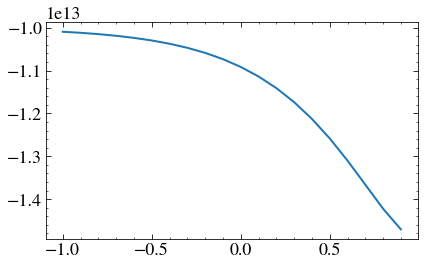

In [138]:
plt.plot(logks_test, fourier_transforms)

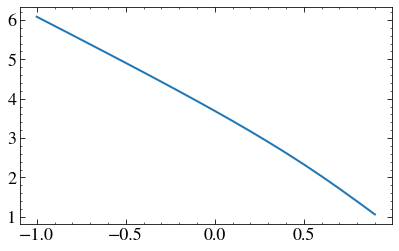

In [134]:
logks_test = np.arange(-1,1,0.1)
ks_test = 10**logks_test
nfw_ft = nfw_fourier_analytical(ks_test, rho_0, rs_0)/M
plt.plot(logks_test, nfw_ft)

In [95]:
nfw_ft_analytical_normalised = nfw_fourier_normalised(k_values, rho_0, r_s)

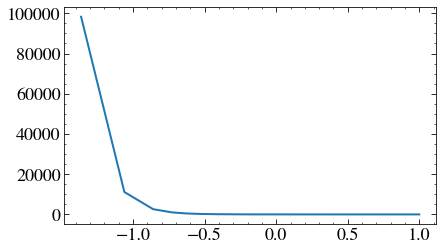

In [97]:
uk_nfw = nfw_fourier_normalised(ks, rho0, rs)
plt.plot(np.log10(ks), uk_nfw)
#plt.ylim(0,1)

In [121]:
import numpy as np
from scipy.special import sici

def nfw_fourier_transform_normalized(k, M, r_s):
    kr_s = k * r_s
    si, _ = sici(kr_s)
    return M * (np.sin(kr_s) * (si - np.pi/2) - np.sin(kr_s) / kr_s)

# Parameters
M = 1.0  # Total mass
r_s = 1.0  # Scale radius
k = 1.0  # Wavenumber

# Compute the normalized Fourier transform
fourier_transform_normalized = nfw_fourier_transform_normalized(k, M, r_s)
print(f"Normalized Fourier transform of NFW profile at k = {k}: {fourier_transform_normalized}")


Normalized Fourier transform of NFW profile at k = 1.0: -1.3671490639166726


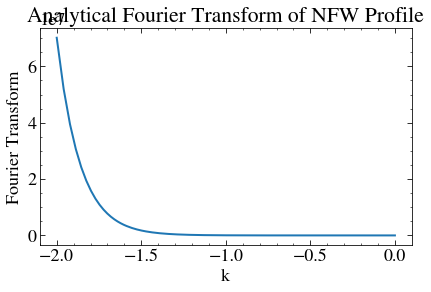

In [76]:
rho_0 = 1.0  # characteristic density
r_s = 1.0    # scale radius

# Define k values
k_values = np.linspace(0.01, 1, 1000)

# Compute the analytical Fourier transform
nfw_ft_analytical = nfw_fourier_analytical(k_values, rho_0, r_s)

# Plot the results
plt.plot(np.log10(k_values), nfw_ft_analytical)
plt.xlabel('k')
plt.ylabel('Fourier Transform')
plt.title('Analytical Fourier Transform of NFW Profile')
plt.show()

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


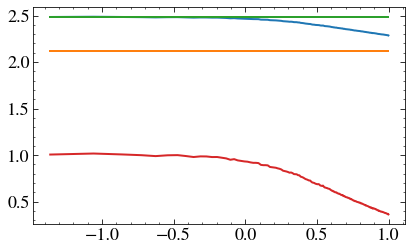

In [37]:
plt.plot(np.log10(ks), np.log10((Pk_gal10["power"][:iend]-(Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"]) )))
plt.plot(np.log10(ks), np.log10([Pk_gal10.attrs["shotnoise"]]*len(ks)))
plt.plot(np.log10(ks), np.log10([Pk_sum10.attrs["shotnoise"]]*len(ks)))
plt.plot(np.log10(ks), uk)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


Text(0, 0.5, '$(P/P_{\\mathrm{linear}})^{1/2}$')

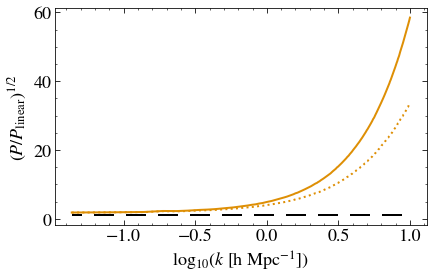

In [10]:
plt.plot([np.log10(ks[0]),np.log10(ks[-1])], [1,1], linestyle=(5, (10/linewidth1, 6/linewidth1)), color="k")

plt.plot(np.log10(ks), np.sqrt(Pk_gal10["power"][:iend]/Pk_linear), label="TNG total", color=color_list1[0])
plt.plot(np.log10(ks),np.sqrt((Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])/Pk_linear), linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
plt.xlabel(r"$\mathrm{log_{10}(}k\ \mathrm{[h\ Mpc^{-1}])}$")
#plt.ylim(0.9,3.5)
plt.ylabel("$(P/P_{\mathrm{linear}})^{1/2}$")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


Text(0, 0.5, '$(P/P_{\\mathrm{linear}})^{1/2}$')

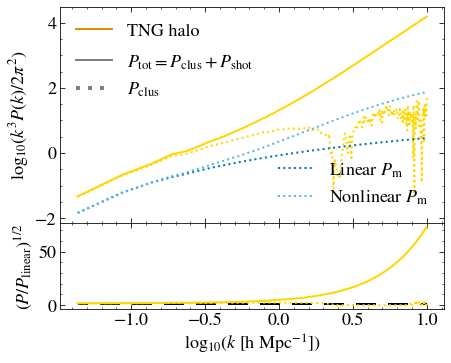

In [26]:
#fig,ax = plt.subplots()
figsize = (2*10/3,2*3)
fig1 = plt.figure(figsize=figsize)
ax = fig1.add_axes((.15,.3,.8,.5))
#plt.plot(np.log10(ks), np.log10(coef * Pk_gal10["power"][:iend]), label="TNG total", color=color_list1[0])
plt.plot(np.log10(ks), np.log10(coef * Pk_sum10["power"][:iend]), label="TNG total", color=color_list1[1])
#plt.plot(np.log10(ks), np.log10(coef * (Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
plt.plot(np.log10(ks), np.log10(coef * (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])), linestyle="dotted", label="TNG clustering (group)", color=color_list1[1])

plt.plot(np.log10(ks), np.log10(normed_Pk_matter_lin), label="linear x 4", color = color_list2[0], linestyle="dotted")
plt.plot(np.log10(ks), np.log10(normed_Pk_matter_nl), label="nonlinear x 4", color = color_list2[1], linestyle="dotted")
plt.xlabel(r"$\mathrm{log_{10}} (k\ \mathrm{[h\ Mpc^{-1}}])$")
plt.ylabel(r"$ \mathrm{log_{10}}(k^3 P(k)/2\pi^2)$")
#plt.xlim(-1.5, 0.5)

label_list = ["TNG halo"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list1[i], linestyle="solid", label=label)
    solid_lines.append(solid_line)

first_legend = ax.legend(handles=solid_lines, frameon=False)
ax.add_artist(first_legend)
label_list = ["Linear $P_\mathrm{m}$", "Nonlinear $P_\mathrm{m}$"]
solid_lines = []
for i, label in enumerate(label_list):
    solid_line = Line2D([],[],color=color_list2[i], linestyle="dotted", label=label)
    solid_lines.append(solid_line)
    
second_legend = ax.legend(handles=solid_lines, frameon=False, loc="lower right", bbox_to_anchor = (1,0))
ax.add_artist(second_legend)

color="grey"
total_ps_leg = Line2D([],[],color=color, linestyle="solid", label=r"$P_\mathrm{tot} = P_{\rm clus} + P_{\rm shot}$")
shotnoise_subtracted_ps_leg = Line2D([],[],color=color,linestyle=(0, (1, 2)), label=r"$P_{\mathrm{clus}}$", linewidth=4)
leg_list = [total_ps_leg, shotnoise_subtracted_ps_leg]
ax.legend(handles=leg_list,bbox_to_anchor=(0,0.5), loc="lower left", frameon=False)

frame2 = fig1.add_axes((.15,.1,.8,.2))

linewidth1=1
plt.plot([np.log10(ks[0]),np.log10(ks[-1])], [1,1], linestyle=(5, (10/linewidth1, 6/linewidth1)), color="k")

#plt.plot(np.log10(ks), np.sqrt(Pk_gal10["power"][:iend]/Pk_linear), label="TNG total", color=color_list1[0])
plt.plot(np.log10(ks), np.sqrt(Pk_sum10["power"][:iend]/(Pk_linear)), label="TNG total", color=color_list1[1])
#plt.plot(np.log10(ks),np.sqrt((Pk_gal10["power"][:iend]-Pk_sum10.attrs["shotnoise"])/Pk_linear), linestyle="dotted", label="TNG clustering (gal)", color="red")
#plt.plot(np.log10(ks),np.sqrt((Pk_gal10["power"][:iend]-Pk_gal10.attrs["shotnoise"])/Pk_linear), linestyle="dotted", label="TNG clustering (gal)", color=color_list1[0])
plt.plot(np.log10(ks), np.sqrt((Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])/Pk_linear), linestyle="dotted", label="TNG clustering (group)", color=color_list1[1])
plt.xlabel(r"$\mathrm{log_{10}(}k\ \mathrm{[h\ Mpc^{-1}])}$")
plt.ylim(0.9,3.5)
plt.ylabel("$(P/P_{\mathrm{linear}})^{1/2}$")
#plt.savefig("../figures/tng_vs_matter.pdf", format="pdf", bbox_inches="tight")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:136: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order, subok=True)


Text(0, 0.5, '$(P/P_{\\mathrm{linear}})^{1/2}$')

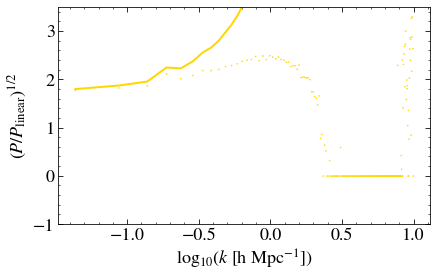

In [33]:
plt.plot(np.log10(ks), np.sqrt(Pk_sum10["power"][:iend]/(Pk_linear)), label="TNG total", color=color_list1[1])
plt.scatter(np.log10(ks), np.sqrt((Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])/Pk_linear), linestyle="dotted", label="TNG clustering (group)", color=color_list1[1],s=1)
plt.xlabel(r"$\mathrm{log_{10}(}k\ \mathrm{[h\ Mpc^{-1}])}$")
plt.ylim(-1,3.5)
plt.ylabel("$(P/P_{\mathrm{linear}})^{1/2}$")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:136: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order, subok=True)


Text(0, 0.5, '$(P/P_{\\mathrm{linear}})$')

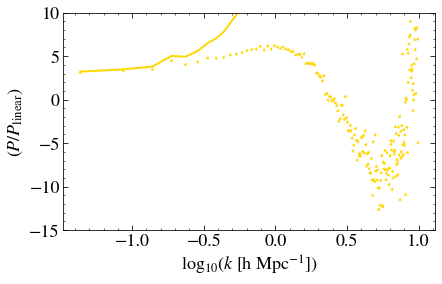

In [40]:
plt.plot(np.log10(ks), Pk_sum10["power"][:iend]/(Pk_linear), label="TNG total", color=color_list1[1])
plt.scatter(np.log10(ks), (Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])/Pk_linear, linestyle="dotted", label="TNG clustering (group)", color=color_list1[1],s=5)
plt.xlabel(r"$\mathrm{log_{10}(}k\ \mathrm{[h\ Mpc^{-1}])}$")
plt.ylim(-15,10)
plt.ylabel("$(P/P_{\mathrm{linear}})$")